# 01a — Model Comparison

Compare one flagship model per provider on the same 100-loan tuning sample,
with and without borrower description.

    "**Models tested:** GPT-5.4 (OpenAI) · Gemini 2.5 Pro (Google Vertex AI) · Gemini 3.5 Flash (Google AI Studio) · Claude Sonnet 4.6 (Anthropic) · Claude Opus 4.8 (Anthropic)\n"

**Conditions:** Structured features only (no_desc) vs. structured features + borrower description (with_desc)

**Note on AUC:** OpenAI and Gemini return token logprobs → AUC computed via `prob_fully_paid`.
Anthropic does not expose logprobs → AUC = n/a for Claude rows; compare on accuracy / F1 / cost.

## Setup

In [1]:
# llm_utils.py and llm_pricing.py live one directory up — make them importable.
import sys; sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np

from llm_utils import (
    load_llm_sample, run_ml_on_sample, run_llm_experiment,
    evaluate_predictions, compare_results, RESULTS_DIR
)

In [2]:
# ── Models to compare (Toggle enabled to easily add/remove models) ─────
MODELS = [
    {"api_provider": "openai",    "model_name": "gpt-5.4",          "label": "GPT-5.4",          "enabled": True,  "with_logprobs": True},
    {"api_provider": "gemini",    "model_name": "gemini-2.5-pro",   "label": "Gemini 2.5 Pro",   "enabled": True,  "with_logprobs": True},
    {"api_provider": "gemini",    "model_name": "gemini-3.5-flash", "label": "Gemini 3.5 Flash", "enabled": True,  "with_logprobs": False},
    {"api_provider": "anthropic", "model_name": "claude-sonnet-4-6","label": "Claude Sonnet 4.6","enabled": True,  "with_logprobs": False},
    {"api_provider": "anthropic", "model_name": "claude-opus-4-8",  "label": "Claude Opus 4.8",  "enabled": True,  "with_logprobs": False},
]

ACTIVE_MODELS = [m for m in MODELS if m.get("enabled", True)]

# Run both conditions for each model
CONDITIONS = [False, True]  # include_desc


In [3]:
# ── Quick OpenAI test — run this once to verify GPT-5.4 response format ────
import openai
from llm_utils import load_api_key, build_system_prompt, build_user_prompt, load_llm_sample

_sample = load_llm_sample()
_system = build_system_prompt()
_user = build_user_prompt(_sample.iloc[0], include_desc=False)

_key = load_api_key("openai")
_client = openai.OpenAI(api_key=_key)
_response = _client.chat.completions.create(
    model="gpt-5.4",
    max_completion_tokens=2048,
    messages=[
        {"role": "system", "content": _system},
        {"role": "user", "content": _user},
    ],
)
print("Full response object:")
print(_response)
print("\n--- choices[0].message ---")
print(_response.choices[0].message)

Full response object:
ChatCompletion(id='chatcmpl-DlLrgVOtQNwD1vk1MBR5ozuEKLcjI', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{"prediction": 1, "reasoning": "The borrower appears more likely to fully repay given the solid B-grade profile, stable income and long employment history, decent FICO around 690, and no recent delinquencies, bankruptcies, or credit inquiries. While revolving utilization and DTI are somewhat elevated, the overall credit history and clean repayment record suggest lower default risk."}', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1780177836, model='gpt-5.4-2026-03-05', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=81, prompt_tokens=502, total_tokens=583, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected

## Load Data & Run XGBoost Baseline

In [4]:
llm_sample = load_llm_sample()
y_true = llm_sample['loan_status'].values

xgb_probs, xgb_preds = run_ml_on_sample(llm_sample)

print(f"Sample size: {len(llm_sample)}")
print(f"Class distribution:\n{llm_sample['loan_status'].value_counts()}")
print(f"\nXGBoost predictions ready: {len(xgb_preds)} samples")

Sample size: 100
Class distribution:
loan_status
1    85
0    15
Name: count, dtype: int64

XGBoost predictions ready: 100 samples


## Run All Experiments

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def run_one(model_cfg, include_desc):
    return run_llm_experiment(
        llm_sample,
        api_provider=model_cfg['api_provider'],
        model_name=model_cfg['model_name'],
        include_desc=include_desc,
        label=model_cfg['label'],
        with_logprobs=model_cfg.get('with_logprobs', True),
    )

# Build list of (model_cfg, include_desc) jobs using ACTIVE_MODELS
jobs = [(m, d) for m in ACTIVE_MODELS for d in CONDITIONS]
print(f"Launching {len(jobs)} experiments in parallel...\n")

all_results = {}
failed = []

with ThreadPoolExecutor(max_workers=len(jobs)) as pool:
    futures = {
        pool.submit(run_one, m, d): (m['label'], 'with_desc' if d else 'no_desc')
        for m, d in jobs
    }
    for future in as_completed(futures):
        label, desc_tag = futures[future]
        try:
            result = future.result()

            all_results[(result['label'], result['desc_tag'])] = result
        except Exception as e:
            failed.append((label, desc_tag, str(e)))
            print(f"\n*** FAILED: {label} ({desc_tag}): {e} ***\n")

print(f"\n{'='*60}")
print(f"Finished: {len(all_results)} succeeded, {len(failed)} failed")
if failed:
    print("Failures:")
    for label, desc_tag, err in failed:
        print(f"  - {label} ({desc_tag}): {err}")


Launching 8 experiments in parallel...

[Gemini 3.1 Pro | with_desc] FAILED on first call: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Logprobs is not enabled for this model', 'status': 'INVALID_ARGUMENT'}}

*** FAILED: Gemini 3.1 Pro (with_desc): [Gemini 3.1 Pro | with_desc] cannot reach API: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Logprobs is not enabled for this model', 'status': 'INVALID_ARGUMENT'}} ***

[Gemini 3.1 Pro | no_desc] FAILED on first call: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Logprobs is not enabled for this model', 'status': 'INVALID_ARGUMENT'}}

*** FAILED: Gemini 3.1 Pro (no_desc): [Gemini 3.1 Pro | no_desc] cannot reach API: 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Logprobs is not enabled for this model', 'status': 'INVALID_ARGUMENT'}} ***

[GPT-5.4 | with_desc] First call OK (pred=1, prob=1.0). Starting full run...


/Users/alemz/Projects/Github/Sabadell_Capstone/notebooks/llm_models/01_model_selection/../llm_utils.py:953: UserWarning: Anthropic API does not expose token logprobs; prob_fully_paid will be None for this provider.
  return call_llm(


[Claude Opus 4.8 | no_desc] First call OK (pred=1, prob=None). Starting full run...
[GPT-5.4 | no_desc] First call OK (pred=1, prob=1.0). Starting full run...
[Claude Opus 4.8 | with_desc] First call OK (pred=1, prob=None). Starting full run...
[Claude Sonnet 4.6 | with_desc] First call OK (pred=1, prob=None). Starting full run...
[Claude Sonnet 4.6 | no_desc] First call OK (pred=1, prob=None). Starting full run...
[GPT-5.4 | with_desc] 10/100 done (21s elapsed, ~191s remaining)
[Claude Opus 4.8 | no_desc] 10/100 done (21s elapsed, ~193s remaining)
[GPT-5.4 | no_desc] 10/100 done (22s elapsed, ~195s remaining)
[Claude Opus 4.8 | with_desc] 10/100 done (24s elapsed, ~220s remaining)
[Claude Sonnet 4.6 | no_desc] 10/100 done (35s elapsed, ~319s remaining)
[Claude Sonnet 4.6 | with_desc] 10/100 done (36s elapsed, ~322s remaining)
[GPT-5.4 | with_desc] 20/100 done (44s elapsed, ~176s remaining)
[GPT-5.4 | no_desc] 20/100 done (44s elapsed, ~176s remaining)
[Claude Opus 4.8 | no_desc] 20/10

## Results Comparison

In [ ]:
# Build summary table
rows = []

# XGBoost baseline
xgb_metrics = evaluate_predictions(y_true, xgb_preds.tolist(), label="XGBoost")
rows.append({'model': 'XGBoost', 'condition': 'structured', **xgb_metrics})

# LLM results
for (label, desc_tag), result in all_results.items():
    condition = 'with_desc' if desc_tag == 'with_desc' else 'no_desc'
    rows.append({'model': label, 'condition': condition, **result['metrics']})

summary = pd.DataFrame(rows)
summary = summary.set_index(['model', 'condition'])
print(summary.to_string())


XGBoost Results (100 samples)
Accuracy: 71.0%

Classification Report:
              precision    recall  f1-score   support

 Charged Off       0.29      0.56      0.38        16
  Fully Paid       0.90      0.74      0.81        84

    accuracy                           0.71       100
   macro avg       0.59      0.65      0.60       100
weighted avg       0.80      0.71      0.74       100

Confusion Matrix:
[[ 9  7]
 [22 62]]
                             accuracy  precision_charged_off  recall_charged_off  f1_charged_off  n_valid
model            condition                                                                               
XGBoost          structured      0.71               0.290323              0.5625        0.382979      100
Gemini 2.5 Flash no_desc         0.61               0.244444              0.6875        0.360656      100
                 with_desc       0.58               0.190476              0.5000        0.275862      100
GPT-5            no_desc         0.

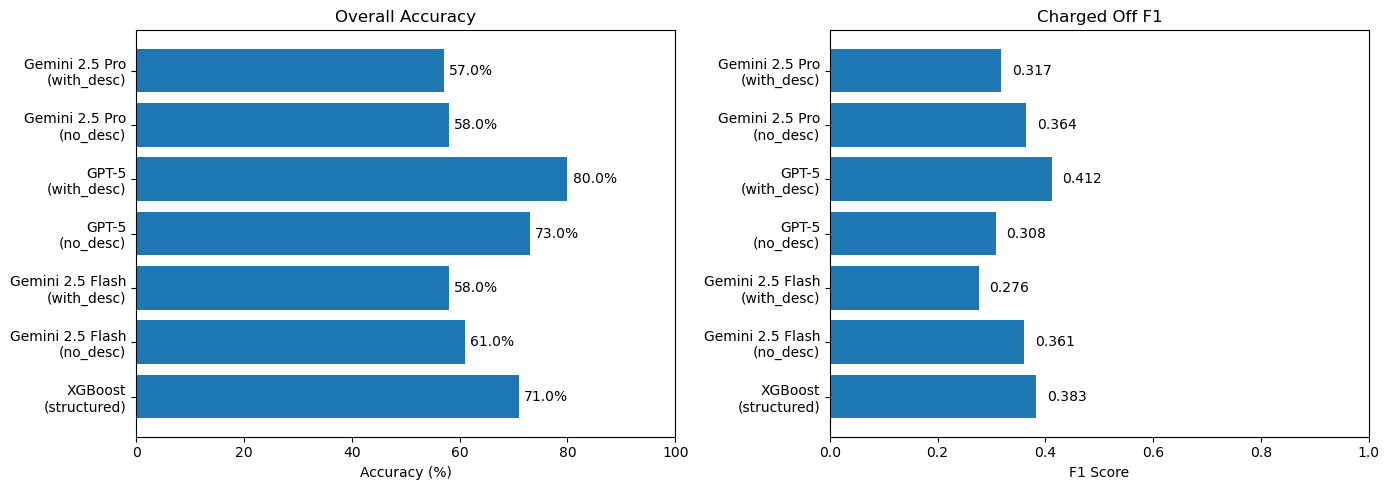

In [ ]:
import matplotlib.pyplot as plt

# Accuracy comparison chart
plot_data = summary.reset_index()
plot_data['label'] = plot_data['model'] + '\n(' + plot_data['condition'] + ')'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].barh(plot_data['label'], plot_data['accuracy'] * 100)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Overall Accuracy')
axes[0].set_xlim(0, 100)
for i, v in enumerate(plot_data['accuracy']):
    axes[0].text(v * 100 + 1, i, f'{v*100:.1f}%', va='center')

# Charged Off F1
axes[1].barh(plot_data['label'], plot_data['f1_charged_off'])
axes[1].set_xlabel('F1 Score')
axes[1].set_title('Charged Off F1')
axes[1].set_xlim(0, 1)
for i, v in enumerate(plot_data['f1_charged_off']):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# Description impact: how much does desc help each model?
print("Impact of adding borrower description:")
print("=" * 60)
for model_cfg in MODELS:
    label = model_cfg['label']
    no_desc = all_results.get((label, 'no_desc'))
    with_desc = all_results.get((label, 'with_desc'))
    if no_desc and with_desc:
        acc_diff = with_desc['metrics']['accuracy'] - no_desc['metrics']['accuracy']
        f1_diff = with_desc['metrics']['f1_charged_off'] - no_desc['metrics']['f1_charged_off']
        
        # Count prediction changes
        changed = sum(a != b for a, b in zip(no_desc['predictions'], with_desc['predictions']))
        improved = sum(
            (a != t and b == t)
            for a, b, t in zip(no_desc['predictions'], with_desc['predictions'], y_true)
        )
        worsened = sum(
            (a == t and b != t)
            for a, b, t in zip(no_desc['predictions'], with_desc['predictions'], y_true)
        )
        print(f"\n{label}:")
        print(f"  Accuracy: {no_desc['metrics']['accuracy']*100:.1f}% -> {with_desc['metrics']['accuracy']*100:.1f}% ({acc_diff*100:+.1f}%)")
        print(f"  CO F1:    {no_desc['metrics']['f1_charged_off']:.3f} -> {with_desc['metrics']['f1_charged_off']:.3f} ({f1_diff:+.3f})")
        print(f"  Predictions changed: {changed}/100 (improved: {improved}, worsened: {worsened})")

Impact of adding borrower description:

Gemini 2.5 Flash:
  Accuracy: 61.0% -> 58.0% (-3.0%)
  CO F1:    0.361 -> 0.276 (-0.085)
  Predictions changed: 15/100 (improved: 6, worsened: 9)

Gemini 2.5 Pro:
  Accuracy: 58.0% -> 57.0% (-1.0%)
  CO F1:    0.364 -> 0.317 (-0.046)
  Predictions changed: 9/100 (improved: 4, worsened: 5)

GPT-5:
  Accuracy: 73.0% -> 80.0% (+7.0%)
  CO F1:    0.308 -> 0.412 (+0.104)
  Predictions changed: 7/100 (improved: 7, worsened: 0)


## Export Results

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save summary metrics
summary.to_csv(f"{RESULTS_DIR}/01a_metrics.csv")

# Save consolidated per-model detailed results into one file:
# rows tagged with model + desc_tag for downstream filtering.
all_predictions = []
for (label, desc_tag), result in all_results.items():
    comparison = compare_results(
        y_true, result['predictions'], xgb_preds.tolist(), result['reasonings']
    )
    comparison.insert(0, 'model', label)
    comparison.insert(1, 'desc_tag', desc_tag)
    all_predictions.append(comparison)

pd.concat(all_predictions, ignore_index=True).to_csv(
    f"{RESULTS_DIR}/01a_predictions.csv", index=False
)

print(f"Results saved to {RESULTS_DIR}/")
print(summary.to_string())